# Extensions - varying one knob at a time (section 6)

The same gap machine, one knob swept per experiment. Internal validity is established in `01_core_snooping.ipynb`; the real-data arc in `02_real_data.ipynb`.

## Setup

In [1]:
import sys, os
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, 'snooping_backend')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from snooping_backend.pipeline import sweep, synthetic_splits, run_once, gap_kfold

## 6.1  Label noise (H2): does more noise widen the gap?
Case 2, sweeping `flip_y`.

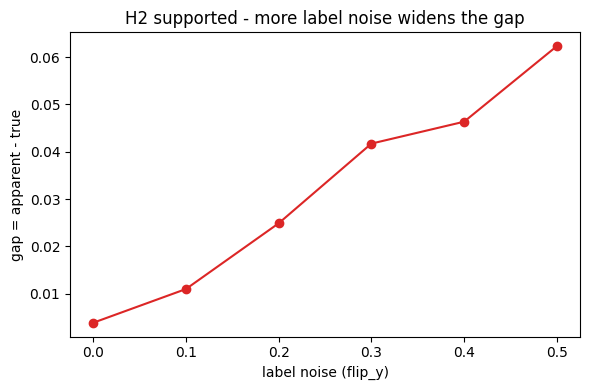

flip_y    gap
   0.0   +0.004
   0.1   +0.011
   0.2   +0.025
   0.3   +0.042
   0.4   +0.046
   0.5   +0.062


In [2]:
flips = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
gap_n = [sweep(synthetic_splits(2, 20, f, [1000, 200, 20000]), [30],
               np.random.default_rng(0), R=15, epochs=60)[30]['gap'] for f in flips]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(flips, gap_n, 'o-', color='#dc2626')
ax.set_xlabel('label noise (flip_y)'); ax.set_ylabel('gap = apparent - true')
ax.set_title('H2 supported - more label noise widens the gap')
fig.tight_layout(); fig.savefig(os.path.join(ROOT, 'figures', 'gap_vs_noise.svg')); plt.show()
print(f"{'flip_y':>6}    gap")
for f, g in zip(flips, gap_n): print(f'{f:>6.1f}   {g:+.3f}')

## 6.2  Model capacity (H3): does a bigger MLP widen the gap?
Case 2 + 30% label noise. At each width we search N configs of that fixed width.

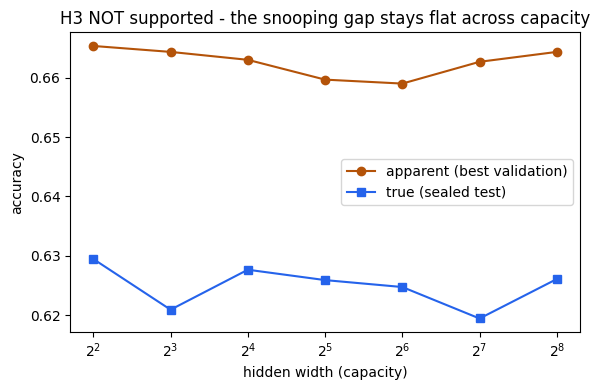

 width  apparent   true     gap
     4    0.665    0.629   +0.036
     8    0.664    0.621   +0.043
    16    0.663    0.628   +0.035
    32    0.660    0.626   +0.034
    64    0.659    0.625   +0.034
   128    0.663    0.619   +0.043
   256    0.664    0.626   +0.038

gap range across capacity: +0.034 to +0.043  (flat -> H3 not supported)


In [3]:
splits = synthetic_splits(2, 20, 0.3, [1000, 200, 20000])
widths = [4, 8, 16, 32, 64, 128, 256]
N, R, epochs = 20, 15, 100
apparent, true, gap = [], [], []
for w in widths:
    sample_w = lambda rng, w=w: {'width': w, 'lr': float(10 ** rng.uniform(-2, 0))}
    r = sweep(splits, [N], np.random.default_rng(0), R=R, epochs=epochs, sample=sample_w)[N]
    apparent.append(r['apparent']); true.append(r['true']); gap.append(r['gap'])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(widths, apparent, 'o-', color='#b45309', label='apparent (best validation)')
ax.plot(widths, true,     's-', color='#2563eb', label='true (sealed test)')
ax.set_xscale('log', base=2)
ax.set_xlabel('hidden width (capacity)'); ax.set_ylabel('accuracy')
ax.set_title('H3 NOT supported - the snooping gap stays flat across capacity')
ax.legend(); fig.tight_layout(); fig.savefig(os.path.join(ROOT, 'figures', 'gap_vs_capacity.svg')); plt.show()
print(f"{'width':>6}  apparent   true     gap")
for w, a, t, g in zip(widths, apparent, true, gap):
    print(f'{w:>6}    {a:.3f}    {t:.3f}   {g:+.3f}')
print(f'\ngap range across capacity: {min(gap):+.3f} to {max(gap):+.3f}  (flat -> H3 not supported)')

## 6.3  Selection protocol (H4): does an honest protocol shrink the gap?
Case 1, fixed data budget. A single small validation split vs honest 5-fold CV (score each config by the mean over k folds, then reveal the test once).

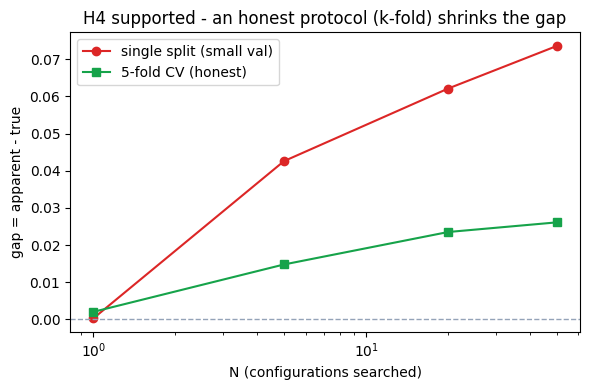

   N   single   k-fold
   1   +0.000   +0.002
   5   +0.043   +0.015
  20   +0.062   +0.024
  50   +0.074   +0.026


In [4]:
case1 = synthetic_splits(1, 20, 0.0, [1000, 200, 20000])
Ns = [1, 5, 20, 50]; Rp = 6
g_single = [np.mean([run_once(case1, n, np.random.default_rng(s), epochs=40)['gap'] for s in range(Rp)]) for n in Ns]
g_kfold  = [np.mean([gap_kfold(case1, n, np.random.default_rng(s), k=5, epochs=40)['gap'] for s in range(Rp)]) for n in Ns]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ns, g_single, 'o-', color='#dc2626', label='single split (small val)')
ax.plot(Ns, g_kfold,  's-', color='#16a34a', label='5-fold CV (honest)')
ax.set_xscale('log'); ax.axhline(0, ls='--', lw=1, color='#94a3b8')
ax.set_xlabel('N (configurations searched)'); ax.set_ylabel('gap = apparent - true')
ax.set_title('H4 supported - an honest protocol (k-fold) shrinks the gap')
ax.legend(); fig.tight_layout(); fig.savefig(os.path.join(ROOT, 'figures', 'gap_vs_protocol.svg')); plt.show()
print(f"{'N':>4}   single   k-fold")
for n, a, b in zip(Ns, g_single, g_kfold): print(f'{n:>4}   {a:+.3f}   {b:+.3f}')